# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
    RANDOM_SEED
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    build_feature_drop_list,
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import (
    plot_daily_pred,
    plot_feature_importances,
)
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    convert_to_serializable,
    get_format,
    optuna_cv_results_to_df,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-13 15:47:26.963 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 50
SECOND_ITER_TRIALS = 250
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    *USELESS_FEATURES,
]

FS_TOP_K = 35
FS_VALID_SIZE = 0.2

MODEL_NAME = "lightgbm_optuna_shap_35"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [5]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [6]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
)
print_best_params(study)

[I 2026-01-13 15:48:06,222] A new study created in memory with name: no-name-83e4a465-d4cd-4f55-8d71-9d015986d93a
[I 2026-01-13 15:48:36,240] Trial 8 finished with value: 0.7151408929521855 and parameters: {'num_leaves': 14, 'max_depth': 3, 'learning_rate': 0.12244673350278082, 'n_estimators': 116, 'subsample': 0.5981472381946008, 'colsample_bytree': 0.6219218717683399, 'min_child_samples': 29, 'reg_alpha': 5.279010574840457, 'reg_lambda': 4.992507575461871}. Best is trial 8 with value: 0.7151408929521855.
[I 2026-01-13 15:48:40,261] Trial 11 finished with value: 0.8199396983038604 and parameters: {'num_leaves': 29, 'max_depth': 3, 'learning_rate': 0.022966295428503838, 'n_estimators': 133, 'subsample': 0.9860705864125886, 'colsample_bytree': 0.7374799424139682, 'min_child_samples': 20, 'reg_alpha': 1.9079281138055137, 'reg_lambda': 5.544138594115712}. Best is trial 8 with value: 0.7151408929521855.
[I 2026-01-13 15:48:47,807] Trial 12 finished with value: 0.7067993990130492 and parame

Best parameters: {'num_leaves': 31, 'max_depth': 5, 'learning_rate': 0.29601833508702186, 'n_estimators': 209, 'subsample': 0.8588888614716731, 'colsample_bytree': 0.8197960051310458, 'min_child_samples': 26, 'reg_alpha': 8.894778857379997, 'reg_lambda': 4.402367844855935}
Best score: 0.69655


In [9]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,mean_test_score,std_test_score,trial_value,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
39,"{'num_leaves': 32, 'max_depth': 5, 'learning_r...",-0.700072,0.066145,0.700072,-0.772819,-0.717602,-0.631330,-0.614075,-0.764532,46
36,"{'num_leaves': 32, 'max_depth': 5, 'learning_r...",-0.699865,0.074972,0.699865,-0.777685,-0.694051,-0.619904,-0.615558,-0.792129,47
40,"{'num_leaves': 32, 'max_depth': 5, 'learning_r...",-0.699457,0.066695,0.699457,-0.767572,-0.707112,-0.631484,-0.615272,-0.775845,48
7,"{'num_leaves': 32, 'max_depth': 3, 'learning_r...",-0.699332,0.065313,0.699332,-0.769852,-0.692508,-0.631423,-0.624988,-0.777888,49
38,"{'num_leaves': 31, 'max_depth': 5, 'learning_r...",-0.696550,0.063515,0.696550,-0.770174,-0.705724,-0.639593,-0.609172,-0.758087,50


### SHAP feature selection

In [10]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
    top_k=FS_TOP_K,
)

In [11]:
FEATURES_TO_DROP = build_feature_drop_list(
    X.columns.tolist(),
    selected_features,
)
FEATURES_TO_KEEP = [c for c in X.columns if c not in FEATURES_TO_DROP]

print("Selected features: ", sorted(selected_features))

Selected features:  ['air_city_te', 'air_genre_te', 'days_from_holiday', 'holiday_flg', 'nbr_res_visitors_diff', 'nbr_res_visitors_diff_mean_14', 'nbr_res_visitors_diff_mean_28', 'nbr_res_visitors_diff_mean_7', 'open_usually', 'opened_recently', 'res_visitors_diff', 'res_visitors_diff_mean_14', 'res_visitors_diff_mean_28', 'res_visitors_diff_mean_7', 'total_reserves', 'total_reserves_nbrs', 'visitors_dow_mean', 'visitors_dow_mean_nbrs', 'visitors_lag_1', 'visitors_lag_28', 'visitors_lag_7', 'visitors_last_month', 'visitors_mean_14', 'visitors_mean_28', 'visitors_mean_7', 'visitors_median_14', 'visitors_median_28', 'visitors_median_7', 'visitors_nbrs_lag_1', 'visitors_nbrs_mean_28', 'visitors_nbrs_median_14', 'visitors_nbrs_std_28', 'visitors_std_14', 'visitors_std_28', 'visitors_std_7']


### Iteration 2

In [12]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=FEATURES_TO_DROP,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
)
print_best_params(study)

[I 2026-01-13 15:54:33,100] A new study created in memory with name: no-name-3d9f2f53-0110-492a-97d4-35e63d1bd41a
[I 2026-01-13 15:54:43,177] Trial 1 finished with value: 0.9101114112111857 and parameters: {'num_leaves': 18, 'max_depth': 3, 'learning_rate': 0.015059768706283751, 'n_estimators': 110, 'subsample': 0.6911753052438967, 'colsample_bytree': 0.8234537520934756, 'min_child_samples': 10, 'reg_alpha': 3.865170733079949, 'reg_lambda': 5.243389512011155}. Best is trial 1 with value: 0.9101114112111857.
[I 2026-01-13 15:54:44,580] Trial 2 finished with value: 0.7222713190964238 and parameters: {'num_leaves': 14, 'max_depth': 4, 'learning_rate': 0.09995174814879706, 'n_estimators': 106, 'subsample': 0.9118698452698155, 'colsample_bytree': 0.5154935448252732, 'min_child_samples': 28, 'reg_alpha': 5.220154164166226, 'reg_lambda': 8.876201767359184}. Best is trial 2 with value: 0.7222713190964238.
[I 2026-01-13 15:54:46,117] Trial 4 finished with value: 0.7230424547884043 and parameter

Best parameters: {'num_leaves': 31, 'max_depth': 5, 'learning_rate': 0.21235729381400928, 'n_estimators': 181, 'subsample': 0.6043099983588278, 'colsample_bytree': 0.9630148647606058, 'min_child_samples': 21, 'reg_alpha': 5.126914320593933, 'reg_lambda': 8.64471170206179}
Best score: 0.69206


In [24]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,mean_test_score,std_test_score,trial_value,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
101,"{'num_leaves': 25, 'max_depth': 3, 'learning_r...",-0.697189,0.062295,0.697189,-0.762921,-0.725757,-0.620861,-0.623863,-0.752543,246
184,"{'num_leaves': 31, 'max_depth': 5, 'learning_r...",-0.697066,0.070574,0.697066,-0.773299,-0.712261,-0.623082,-0.606996,-0.769694,247
116,"{'num_leaves': 24, 'max_depth': 3, 'learning_r...",-0.696473,0.064697,0.696473,-0.776203,-0.701866,-0.622307,-0.623981,-0.758011,248
245,"{'num_leaves': 32, 'max_depth': 5, 'learning_r...",-0.694966,0.077150,0.694966,-0.780584,-0.706046,-0.614466,-0.598279,-0.775456,249
173,"{'num_leaves': 31, 'max_depth': 5, 'learning_r...",-0.692056,0.069222,0.692056,-0.781196,-0.707510,-0.617862,-0.606832,-0.746879,250


### Scores

In [13]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.8254
MAE:  6.4415
R2:   0.6657


In [17]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[18.47267981 12.62517958  7.92237842  5.52901447  4.47737971 18.48416558
 11.34903204 42.37763757 31.68384857  7.42387414 33.08843352  3.80265432
 18.50181836 30.48422092 13.74902128  8.54390363  0.16157104  7.06235681
  3.62824747 29.46320842 19.82732881 40.62467019  5.41038883 11.66666148
  9.02307202 13.76347727  4.75770838  7.82046672  7.38690571 26.95485078
  0.         40.16756076 27.74907384  5.82842281  0.36664754 26.798005
  7.87009978  3.24066834 10.57376038  9.77154219  1.39041266  7.38591684
 14.09334308  5.40733287  0.06017589 19.10586602  9.10187029 41.67227391
  8.11397545 28.61893614 17.6068889   5.38394055 34.39836937 14.02600294
  5.26155188  5.02926912  0.          8.17144456 16.25927841  7.07024

In [18]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8316
MAE:  7.1624
R2:   0.5480


## Graphs

### Feature importances

<Figure size 1200x1000 with 0 Axes>

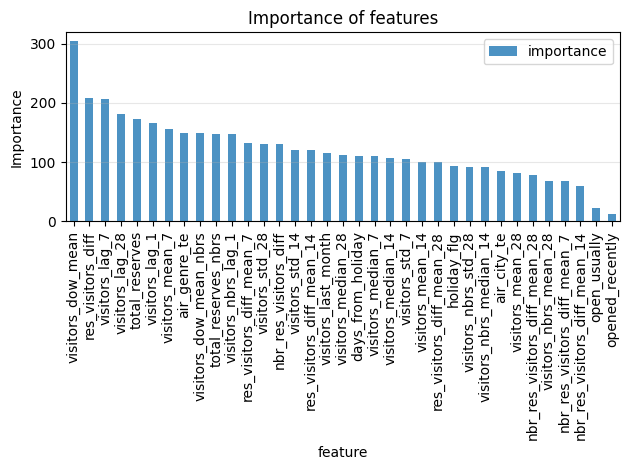

In [19]:
plot_feature_importances(model_shap, FEATURES_TO_KEEP)

## SHAP explanation

In [20]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

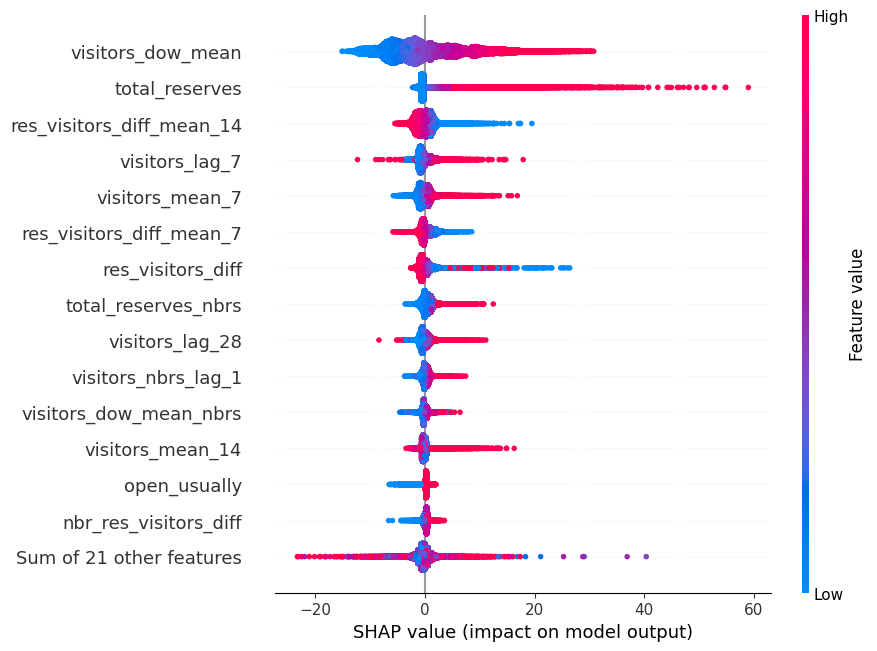

In [21]:
shap.plots.beeswarm(shap_values, max_display=15)

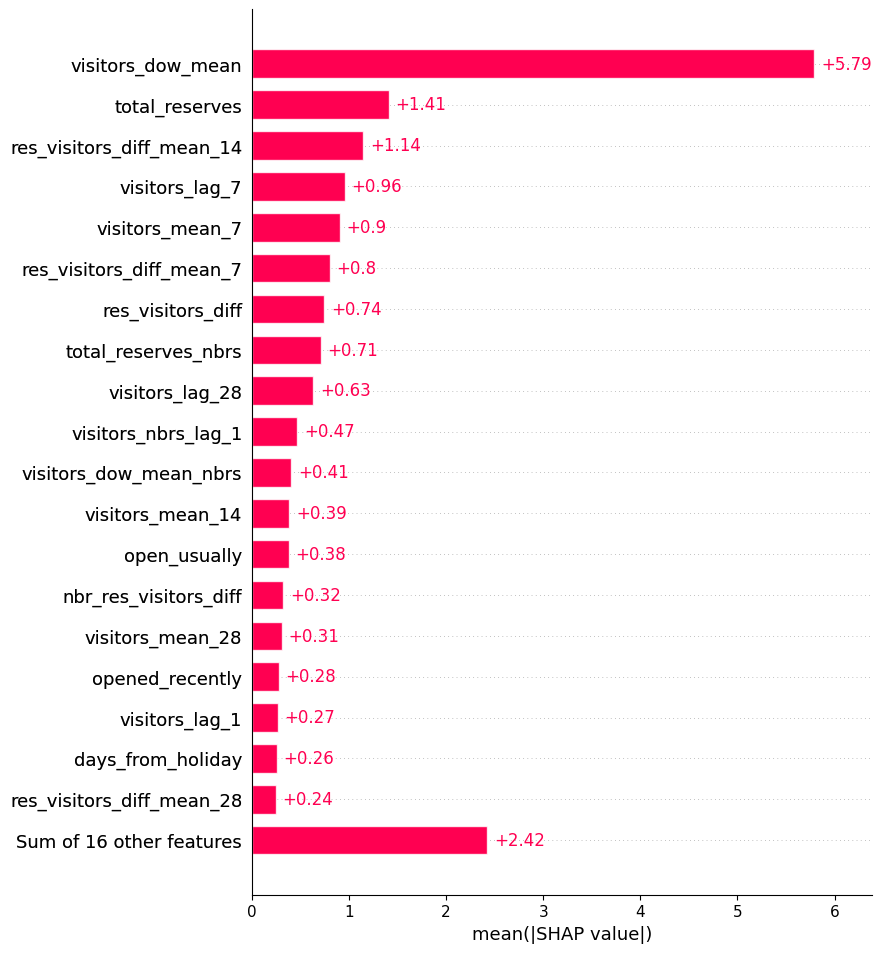

In [22]:
shap.plots.bar(shap_values, max_display=20)

### Visitors per day: actual vs predicted

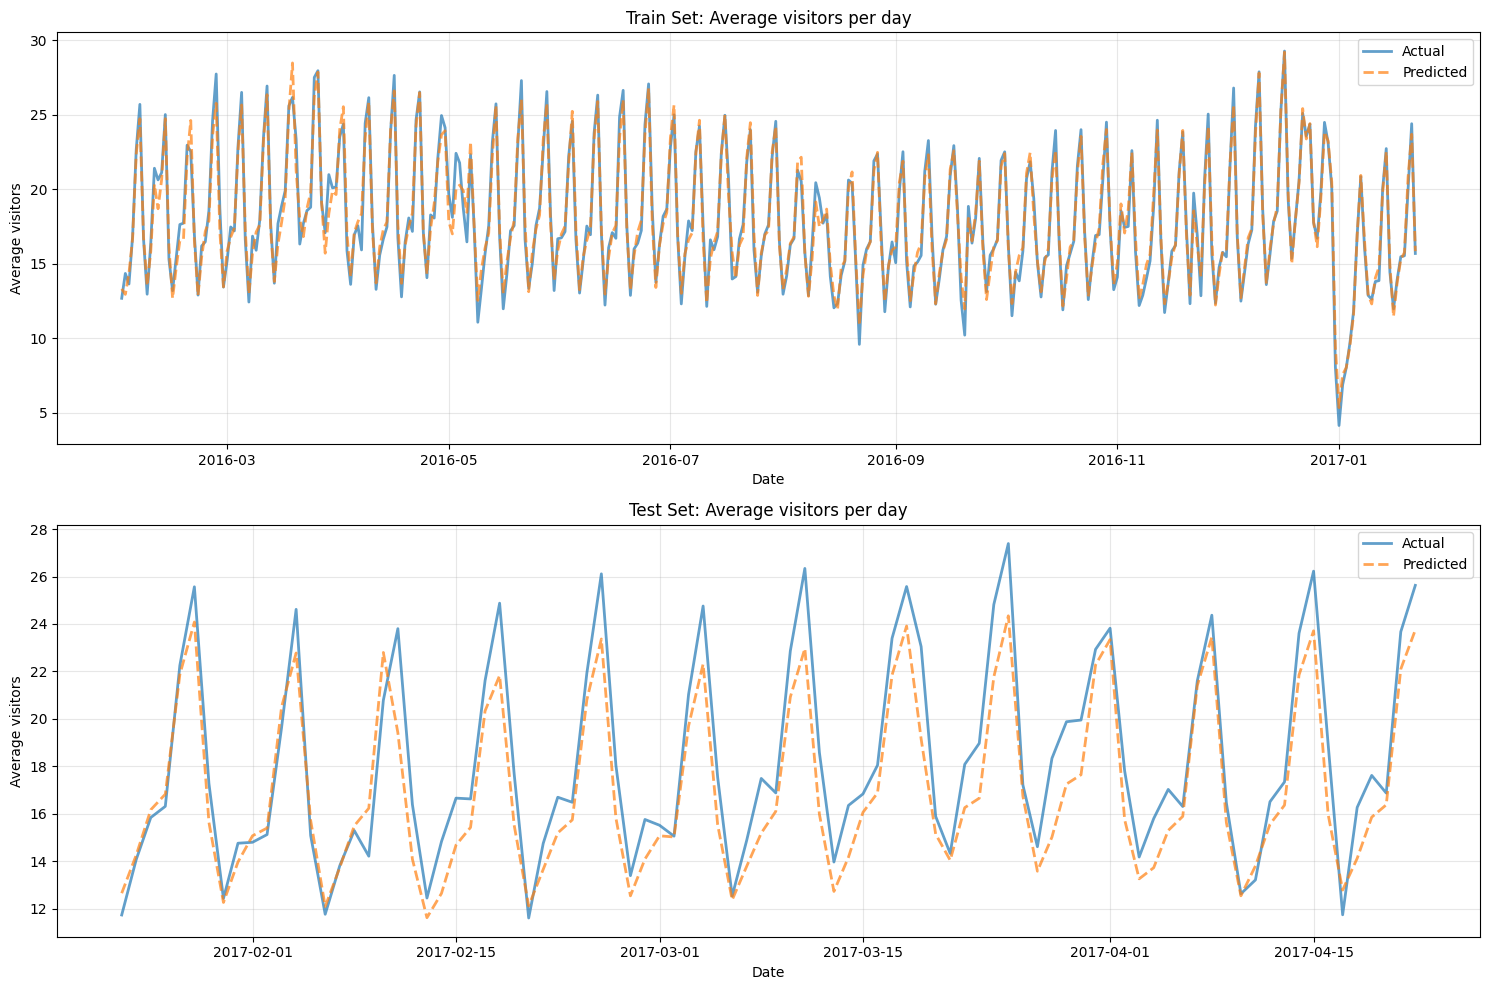

In [23]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [29]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [30]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00000000e+00 6.12209713e-01 9.70588330e+00 4.50083908e+00
 2.44940147e+01 2.21389795e+01 2.73485592e+01 0.00000000e+00
 3.84079447e+01 1.44774626e+00 2.06061386e+01 3.89515897e+00
 2.78037463e+01 4.74876616e+01 2.22866878e+01 4.40203896e+00
 1.31106016e+01 1.19426590e+01 2.65071090e+01 5.16925102e+01
 4.78111556e+00 8.38670795e+00 1.42748341e+01 1.88521204e+01
 1.10601491e+00 2.75418503e+01 1.17493107e+01 1.55310709e+01
 4.80925274e-01 1.34041224e+01 1.92488447e+01 3.27467070e+00
 1.94478778e+01 8.74781456e+00 6.42934376e+00 2.58563995e+00
 1.77230211e+00 3.32225389e+01 2.20562053e+01 1.30452752e+01
 3.60390303e+01 3.86252565e+01 5.98325315e+00 9.84257892e-02
 1.31626025e+01 1.59742814e+01 3.51436080e-01 1.16031

In [31]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [28]:
joblib.dump(model_shap, MODEL_PATH)
params_to_save = {
    "best_params": convert_to_serializable(study.best_params),
    "best_score": float(study.best_value),
    "std": float(cv_results.sort_values(["rank_test_score"]).iloc[0]["std_test_score"]),
    "features": FEATURES_TO_KEEP
}

PARAMS_PATH = MODELS_DIR / f"{MODEL_NAME}_params.json"
with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)